### Chatbot using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

### State


In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

### Model Keys

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

### Invoke Model

In [26]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3.8-27b", max_tokens=200)
llm_groq.invoke("Hello I am Jay, wants to read AI news today")

AIMessage(content="Hello Jay! 👋\n\nI'm happy to help you catch up on AI news. However, please note that **I don't have real-time access to today's live news feeds**. My knowledge cutoff is in the past, so I can't tell you exactly what broke *this morning*.\n\nThat said, I can help you in a few ways:\n\n1. **Summarize recent major AI trends** up to my last update (e.g., developments in LLMs, AI regulation, major product launches from OpenAI, Google, Anthropic, etc.).\n2. **Recommend reliable sources** where you can get today’s latest AI news:\n   - **TechCrunch AI**\n   - **The Verge / AI section**\n   - **Ars Technica**\n   - **MIT Technology Review**\n   - **Hacker News** (often has fresh AI discussions)\n   - **AI-specific newsletters**: The Batch (DeepLearning.AI),", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 200, 'prompt_tokens': 23, 'total_tokens': 223, 'completion_time': 0.39362773, 'completion_tokens_details': None, 'prompt_time': 0.001500177, 

### Create Nodes

In [20]:
def si_bot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

### Build ChatBot Graph

In [21]:
graph=StateGraph(State)

## Node
graph.add_node("SiBot",si_bot)

## Edges
graph.add_edge(START,"SiBot")
graph.add_edge("SiBot",END)

graph_builder=graph.compile()

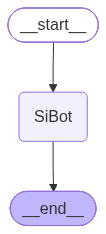

In [22]:

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [29]:
graph_builder.invoke({"messages": "Write top 3 AI News items!"})

{'messages': [HumanMessage(content='Write top 3 AI News items!', additional_kwargs={}, response_metadata={}, id='711b6233-67a7-4f2b-98f5-877d9ab5b93c'),
  AIMessage(content='Here are three of the most significant and recent developments in the AI news landscape (as of mid-2024):\n\n### 1. The Rise of Multimodal and Agentic AI\nLeading AI labs are rapidly shifting focus from simple chatbots to **multimodal models** (capable of understanding text, images, audio, and video simultaneously) and **autonomous agents**. \n- **Key Development**: Models like GPT-4o, Gemini 1.5 Pro, and Claude 3.5 Sonnet are demonstrating real-time voice interaction and the ability to perform multi-step tasks (e.g., browsing the web, executing code, and filling out forms) with minimal human intervention.\n- **Impact**: This marks a transition from "AI as a tool" to "AI as an assistant," with companies integrating these capabilities into productivity suites (Microsoft Copilot, Google Workspace) and enterprise work

### Steaming Response

In [30]:
for event in graph_builder.stream({"messages":"Wow, what a good weather!!"}):
    print(event)

{'SiBot': {'messages': [AIMessage(content="I'm so glad you're enjoying it! ☀️ It really does make the day feel brighter.\n\nWhat are you up to to take advantage of the nice weather? Are you heading outside for a walk, having a picnic, or just enjoying it from a nice spot? 🌿☕", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 19, 'total_tokens': 81, 'completion_time': 0.117859218, 'completion_tokens_details': None, 'prompt_time': 0.001009005, 'prompt_tokens_details': None, 'queue_time': 0.023471995, 'total_time': 0.118868223}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_c14f15bfae', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1038f-662a-7a63-9384-73afaac23300-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 62, 'total_tokens': 81})]}}
